# **Heterogeneous Absorber in a 1D Reactor**

This notebook extends the bare slab reactor model by introducing a localised
region of increased neutron absorption.

The numerical model is used to investigate how a heterogeneous absorber
affects the effective multiplication factor and the fundamental neutron flux.
A convergence study is then used to examine the accuracy of the
finite-difference method.

## Introduction

In the previous notebook, the reactor was modelled as a homogeneous slab with
constant material properties. An analytical solution was therefore available
for validating the numerical method.

Here, the absorption cross section varies with position. A localised region
of increased absorption is used as a simple model of a partially inserted
control rod.

The aims of this notebook are to:

- calculate the effective multiplication factor $k_{\mathrm{eff}}$;
- examine how the absorber changes the fundamental flux profile;
- compare the heterogeneous and homogeneous cases;
- investigate the convergence of the numerical solution;
- understand how the discontinuity in the absorber profile affects the observed
  convergence order.

## Theory

The one-group, one-dimensional diffusion equation can be written as

$$
-D\frac{d^2\phi}{dx^2}
+
\Sigma_a(x)\phi
=
\frac{1}{k_{\mathrm{eff}}}\nu\Sigma_f\phi,
$$

where:

- $D$ is the diffusion coefficient;
- $\Sigma_a(x)$ is the position-dependent absorption cross section;
- $\nu\Sigma_f$ is the neutron production cross section;
- $\phi(x)$ is the neutron flux;
- $k_{\mathrm{eff}}$ is the effective multiplication factor.

The main difference from the previous homogeneous model is that
$\Sigma_a$ now depends on position.

Using a second-order central finite-difference approximation for the second
derivative gives a matrix eigenvalue problem,

$$
A\phi
=
\frac{1}{k_{\mathrm{eff}}}\nu\Sigma_f\phi.
$$

The smallest eigenvalue of the corresponding matrix determines the largest
value of $k_{\mathrm{eff}}$, which corresponds to the fundamental reactor
mode.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Reactor parameters
D = 0.9              # Diffusion coefficient [cm]
nu_Sigma_f = 0.12    # Neutron production cross section [1/cm]

# Spatial domain
a = 200.0            # Slab width [cm]
N = 500              # Number of interior grid points

dx = a / (N + 1)
x = np.linspace(dx, a - dx, N)

# Absorption cross section
Sigma_a_base = 0.1    # Background absorption [1/cm]
Sigma_a_bump = 0.15   # Additional absorption in the absorber [1/cm]

# Absorber geometry
rod_center = a / 2
rod_width = 20.0

### Absorption Profile

The absorption cross section consists of a uniform background value together
with an additional contribution inside the absorber:

$$
\Sigma_a(x)
=
\Sigma_{a,\mathrm{base}}
+
\Delta\Sigma_a(x).
$$

The absorber is initially represented by a sharp step function.

In [2]:
# Define the sharp absorber region
absorber = np.abs(x - rod_center) < rod_width / 2

# Spatially varying absorption cross section
Sigma_a = Sigma_a_base + Sigma_a_bump * absorber

### Spatial Absorption Profile

The absorption cross section is increased in the central absorber region while
remaining at the background value elsewhere in the reactor.

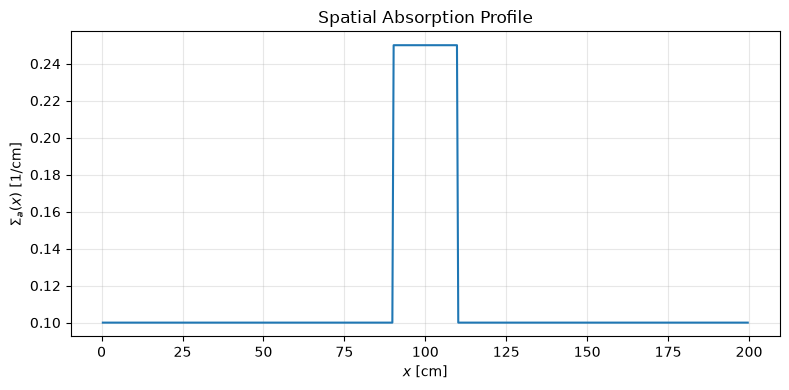

In [3]:
plt.figure(figsize=(8, 4))

plt.plot(x, Sigma_a)

plt.xlabel(r"$x$ [cm]")
plt.ylabel(r"$\Sigma_a(x)$ [1/cm]")
plt.title("Spatial Absorption Profile")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Numerical Solution

The diffusion operator is discretised using the same second-order central
finite-difference scheme as in the previous notebook.

The spatially varying absorption term is then added as a diagonal matrix.

In [4]:
# Finite-difference diffusion operator
main_diag = 2.0 * D * np.ones(N) / dx**2
off_diag = -1.0 * D * np.ones(N - 1) / dx**2

L = (
    np.diag(main_diag)
    + np.diag(off_diag, k=1)
    + np.diag(off_diag, k=-1)
)

# Add the spatially varying absorption term
A_matrix = L + np.diag(Sigma_a)

# Convert to a standard eigenvalue problem
M = A_matrix / nu_Sigma_f

eigenvalues, eigenvectors = np.linalg.eigh(M)

### Effective Multiplication Factor

Since

$$
M\phi = \frac{1}{k_{\mathrm{eff}}}\phi,
$$

the smallest eigenvalue of $M$ corresponds to the largest
$k_{\mathrm{eff}}$.

In [5]:
# The smallest eigenvalue corresponds to the fundamental mode
idx_fundamental = np.argmin(eigenvalues)

k_eff = 1.0 / eigenvalues[idx_fundamental]

print(f"k_eff = {k_eff:.6f}")

k_eff = 1.187666


### Fundamental Flux Profile

The eigenvector corresponding to the smallest eigenvalue gives the
fundamental flux mode.

The absolute scale of the flux is arbitrary, so the numerical solution is
normalised to have a maximum magnitude of one.

In [6]:
phi_num = eigenvectors[:, idx_fundamental]

# Normalise the flux
phi_num = phi_num / np.max(np.abs(phi_num))

# Choose a positive sign convention
if phi_num[N // 2] < 0:
    phi_num = -phi_num

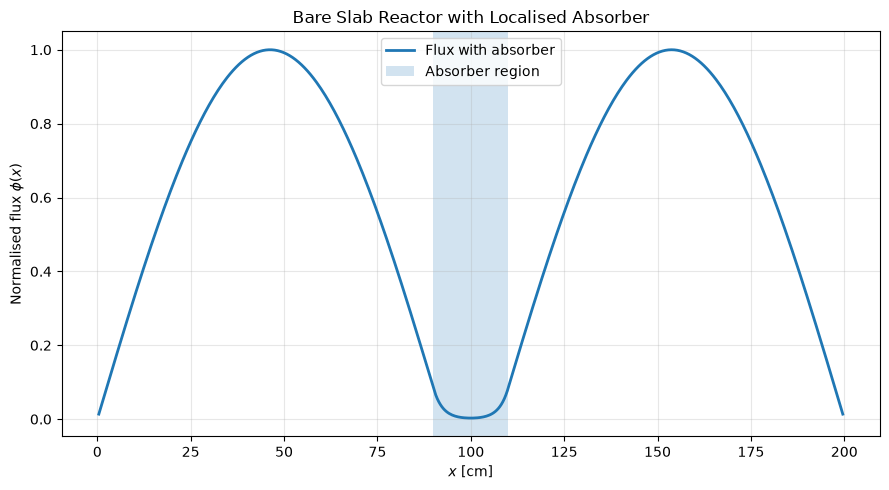

In [7]:
plt.figure(figsize=(9, 5))

plt.plot(
    x,
    phi_num,
    linewidth=2,
    label="Flux with absorber"
)

plt.axvspan(
    rod_center - rod_width / 2,
    rod_center + rod_width / 2,
    alpha=0.2,
    label="Absorber region"
)

plt.xlabel(r"$x$ [cm]")
plt.ylabel(r"Normalised flux $\phi(x)$")
plt.title("Bare Slab Reactor with Localised Absorber")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../assets/heterogeneous_flux_profile.png", dpi=150)
plt.show()

## Comparison with the Homogeneous Reactor

To see the effect of the absorber, the homogeneous reactor from the previous
notebook is solved again using the same grid and material parameters.

This provides a direct comparison between the two flux profiles.

In [8]:
# Homogeneous absorption profile
Sigma_a_homog = Sigma_a_base * np.ones(N)

A_homog = L + np.diag(Sigma_a_homog)
M_homog = A_homog / nu_Sigma_f

eigvals_homog, eigvecs_homog = np.linalg.eigh(M_homog)

idx_homog = np.argmin(eigvals_homog)

phi_homog = eigvecs_homog[:, idx_homog]

# Normalise the homogeneous flux
phi_homog = phi_homog / np.max(np.abs(phi_homog))

# Choose a positive sign convention
if phi_homog[N // 2] < 0:
    phi_homog = -phi_homog

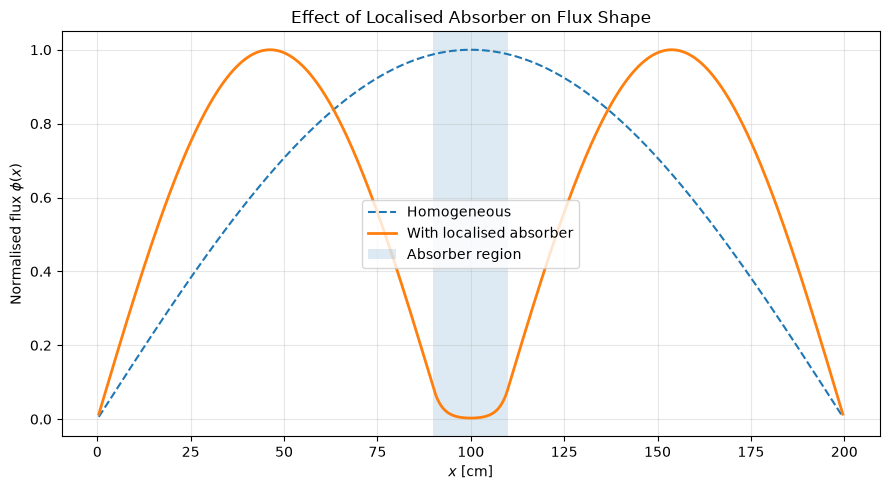

In [9]:
plt.figure(figsize=(9, 5))

plt.plot(
    x,
    phi_homog,
    "--",
    linewidth=1.5,
    label="Homogeneous"
)

plt.plot(
    x,
    phi_num,
    linewidth=2,
    label="With localised absorber"
)

plt.axvspan(
    rod_center - rod_width / 2,
    rod_center + rod_width / 2,
    alpha=0.15,
    label="Absorber region"
)

plt.xlabel(r"$x$ [cm]")
plt.ylabel(r"Normalised flux $\phi(x)$")
plt.title("Effect of Localised Absorber on Flux Shape")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../assets/heterogeneous_vs_homogeneous_flux.png", dpi=150)
plt.show()

## Results

The localised absorber reduces the effective multiplication factor from

$$
k_{\mathrm{eff}} \approx 1.19734
$$

in the homogeneous reactor to

$$
k_{\mathrm{eff}} \approx 1.18767.
$$

This reduction is consistent with the physical effect of introducing
additional absorption without adding any additional neutron production.

The flux profile is also changed significantly. The homogeneous reactor has a
single smooth maximum at the centre of the slab, while the absorber reduces
the flux in the central region and causes the flux to redistribute towards
the regions on either side of the absorber.

## Convergence Analysis

Unlike the homogeneous bare slab, this heterogeneous system does not have a
simple analytical solution that can be used directly to calculate the
numerical error.

A high-resolution calculation with $N=4000$ grid points is therefore used as
a reference solution. The numerical solutions at lower resolutions are
compared with this reference.

In [10]:
def solve_heterogeneous_slab(
    N,
    a=200.0,
    D=0.9,
    nu_Sigma_f=0.12,
    Sigma_a_base=0.1,
    Sigma_a_bump=0.15,
    rod_center=100.0,
    rod_width=20.0,
):
    dx = a / (N + 1)
    x = np.linspace(dx, a - dx, N)

    # Spatially varying absorption
    absorber = np.abs(x - rod_center) < rod_width / 2
    Sigma_a = Sigma_a_base + Sigma_a_bump * absorber

    # Finite-difference diffusion operator
    main_diag = 2.0 * D * np.ones(N) / dx**2
    off_diag = -1.0 * D * np.ones(N - 1) / dx**2

    L = (
        np.diag(main_diag)
        + np.diag(off_diag, k=1)
        + np.diag(off_diag, k=-1)
    )

    A_matrix = L + np.diag(Sigma_a)
    M = A_matrix / nu_Sigma_f

    eigenvalues, eigenvectors = np.linalg.eigh(M)

    idx = np.argmin(eigenvalues)

    k_eff = 1.0 / eigenvalues[idx]

    phi = eigenvectors[:, idx]
    phi = phi / np.max(np.abs(phi))

    if phi[N // 2] < 0:
        phi = -phi

    return x, dx, k_eff, phi

In [11]:
# High-resolution reference solution
N_ref = 4000

x_ref, dx_ref, k_ref, phi_ref = solve_heterogeneous_slab(N_ref)

print(f"Reference k_eff (N={N_ref}): {k_ref:.6f}")

Reference k_eff (N=4000): 1.187659


### Convergence with Grid Resolution

The calculation is repeated for several grid resolutions. The relative error
in $k_{\mathrm{eff}}$ is measured against the high-resolution reference:

$$
\text{relative error}
=
\frac{|k_{\mathrm{eff}}-k_{\mathrm{ref}}|}
{k_{\mathrm{ref}}}.
$$

In [12]:
N_values = [50, 100, 200, 400, 800, 1600]

k_errors = []

for N in N_values:
    _, dx, k_eff, _ = solve_heterogeneous_slab(N)

    error = abs(k_eff - k_ref) / k_ref
    k_errors.append(error)

k_errors = np.array(k_errors)

h_values = a / (np.array(N_values) + 1)

print("Relative errors:", k_errors)

Relative errors: [2.29275006e-04 6.77071194e-05 2.25233005e-05 8.01469518e-06
 2.95887263e-06 9.95572403e-07]


In [13]:
# Fit log(error) = p log(h) + constant
k_order = np.polyfit(
    np.log(h_values),
    np.log(k_errors),
    1
)[0]

print(f"k_eff convergence order: {k_order:.3f}")

k_eff convergence order: 1.559


In [14]:
# Repeat the fit without the finest grid
k_order_excl = np.polyfit(
    np.log(h_values[:-1]),
    np.log(k_errors[:-1]),
    1
)[0]

print(
    "k_eff convergence order "
    f"(excluding N=1600): {k_order_excl:.3f}"
)

k_eff convergence order (excluding N=1600): 1.573


## Investigating the Reduced Convergence Order

The initial convergence study gives a fitted order of approximately
$1.56$--$1.57$, which is below the expected second-order behaviour of the
central finite-difference scheme.

This raises the question of why the convergence is slower for the
heterogeneous reactor.

One possible explanation is the sharp discontinuity in the absorption cross
section at the edges of the absorber. To investigate this, the calculation
can be repeated using a smooth transition between the background and
absorbing regions.

In [15]:
def solve_heterogeneous_slab_smooth(
    N,
    a=200.0,
    D=0.9,
    nu_Sigma_f=0.12,
    Sigma_a_base=0.1,
    Sigma_a_bump=0.15,
    rod_center=100.0,
    rod_width=20.0,
    smoothness=2.0,
):
    dx = a / (N + 1)
    x = np.linspace(dx, a - dx, N)

    # Smooth absorber profile using hyperbolic tangent transitions
    left_edge = rod_center - rod_width / 2
    right_edge = rod_center + rod_width / 2

    profile = 0.5 * (
        np.tanh(smoothness * (x - left_edge))
        - np.tanh(smoothness * (x - right_edge))
    )

    Sigma_a = Sigma_a_base + Sigma_a_bump * profile

    # Finite-difference diffusion operator
    main_diag = 2.0 * D * np.ones(N) / dx**2
    off_diag = -1.0 * D * np.ones(N - 1) / dx**2

    L = (
        np.diag(main_diag)
        + np.diag(off_diag, k=1)
        + np.diag(off_diag, k=-1)
    )

    A_matrix = L + np.diag(Sigma_a)
    M = A_matrix / nu_Sigma_f

    eigenvalues, _ = np.linalg.eigh(M)

    k_eff = 1.0 / eigenvalues[0]

    return k_eff

In [ ]:
N_ref = 4000
k_ref_smooth = solve_heterogeneous_slab_smooth(N_ref)

k_errors_smooth = []

for N in N_values:
    k_eff = solve_heterogeneous_slab_smooth(N)

    error = abs(k_eff - k_ref_smooth) / k_ref_smooth
    k_errors_smooth.append(error)

k_errors_smooth = np.array(k_errors_smooth)

k_order_smooth = np.polyfit(
    np.log(h_values),
    np.log(k_errors_smooth),
    1
)[0]

print(
    f"k_eff convergence order (smooth profile): "
    f"{k_order_smooth:.3f}"
)

### Interpretation

The sharp absorber gives a convergence order of approximately $1.56$--$1.57$,
whereas the smoothed absorber gives an order of approximately $2.38$.

The change in convergence behaviour supports the idea that the sharp
discontinuity in $\Sigma_a(x)$ is an important source of the reduced
convergence rate.

The central finite-difference discretisation remains second-order, but the
presence of a discontinuous material coefficient means that the assumptions
behind the usual smooth-solution error analysis are not satisfied everywhere
in the domain.

The smooth-profile calculation provides a useful controlled test: when the
material transition is made smooth, the observed convergence returns to
approximately second-order behaviour.

## Discussion

The heterogeneous reactor behaves as expected physically: introducing a
region of increased absorption reduces the effective multiplication factor
and changes the shape of the fundamental flux.

The reduction in $k_{\mathrm{eff}}$ from approximately $1.19734$ in the
homogeneous case to $1.18767$ shows that the additional absorption reduces
the reactor's reactivity. The flux is also depressed within the absorber
region, with the surrounding regions carrying a larger proportion of the
flux.

The convergence study gives a more interesting numerical result. The sharp
absorber produces a fitted convergence order of approximately $1.56$--$1.57$,
rather than the expected $O(h^2)$ behaviour of the central finite-difference
scheme. Repeating the calculation with a smooth absorber profile gives a
fitted order of approximately $2.38$.

This comparison suggests that the discontinuity in the absorption cross
section is an important source of the reduced convergence rate. The
finite-difference stencil itself has not changed; instead, the material
coefficient changes abruptly at the absorber boundaries.

The result also highlights an important difference between the homogeneous
and heterogeneous problems. In the homogeneous case, an analytical solution
is available and provides a direct validation of the numerical method. In
the heterogeneous case, no simple analytical solution is available, so a
high-resolution numerical solution must be used as a reference.

The smooth-profile experiment therefore provides useful evidence that the
observed reduction in convergence is associated with the material
discontinuity rather than simply being a problem with the finite-difference
implementation.

## Conclusion

A one-dimensional reactor diffusion model with a localised absorbing region
was implemented using the same finite-difference approach as the homogeneous
bare slab.

The additional absorption reduced the effective multiplication factor from
approximately $1.19734$ to $1.18767$ and significantly changed the shape of
the fundamental flux, producing a depression in the absorber region.

Since no simple analytical solution is available for the heterogeneous
reactor, convergence was assessed against a high-resolution numerical
reference. The sharp absorber produced a convergence order of approximately
$1.56$--$1.57$, below the second-order behaviour observed for the homogeneous
case.

A controlled experiment using a smooth absorber profile gave a convergence
order of approximately $2.38$. This supports the conclusion that the sharp
material discontinuity is responsible for much of the reduced convergence
rate.

Overall, the calculation demonstrates how spatially varying material
properties affect both the physical solution and the numerical behaviour of
the finite-difference method.